In [46]:
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model  import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [47]:
df=pd.read_csv('day16_flight_delay_prediction.csv')
df

,Flight_ID,Airline,Departure_Airport,Arrival_Airport,Flight_Date,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,...,Weather_Condition,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Air_Traffic_Level,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
0,FLIGHT_0012629,Vistara,GOI,COK,2025-01-11,6,5,1,1227.19,3.7,...,Fog,1.39,20.99,44.05,Low,26.75,1.67,0.57,47,1
1,FLIGHT_0037731,Vistara,GOI,COK,2025-04-05,23,5,1,1619.77,7.6,...,Fog,0.93,9.15,27.54,Low,4.75,4.43,1.47,32,1
2,FLIGHT_0039992,Vistara,HYD,PNQ,2025-11-11,9,1,0,2213.07,15.3,...,Clear,11.52,43.04,62.31,Medium,10.87,28.05,2.49,24,1
3,FLIGHT_0008526,IndiGo,PNQ,MAA,2025-09-15,10,0,0,2494.51,6.0,...,Rain,5.50,18.53,81.15,High,7.47,7.80,0.15,23,1
4,FLIGHT_0008280,IndiGo,BOM,HYD,2025-11-13,8,3,0,1463.73,11.7,...,Rain,6.42,15.86,72.48,Medium,8.44,13.68,1.26,36,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,FLIGHT_0054344,IndiGo,BOM,PNQ,2025-05-04,9,6,1,205.26,9.7,...,Clear,12.23,13.88,80.60,High,11.34,2.64,3.46,17,1
59996,FLIGHT_0038159,Air India,HYD,AMD,2025-12-20,19,5,1,425.55,4.6,...,Clear,13.38,8.89,79.14,High,1.28,1.34,0.52,10,0
59997,FLIGHT_0000861,SpiceJet,GOI,DEL,2025-10-31,5,4,0,714.87,16.8,...,Fog,0.90,1.76,27.44,Low,0.87,4.23,0.29,19,1
59998,FLIGHT_0015796,IndiGo,AMD,BOM,2025-09-03,18,2,0,842.70,1.7,...,Heavy Rain,6.31,17.77,45.42,Low,15.14,6.25,0.82,48,1


In [48]:
df.head()

,Flight_ID,Airline,Departure_Airport,Arrival_Airport,Flight_Date,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,...,Weather_Condition,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Air_Traffic_Level,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
0,FLIGHT_0012629,Vistara,GOI,COK,2025-01-11,6,5,1,1227.19,3.7,...,Fog,1.39,20.99,44.05,Low,26.75,1.67,0.57,47,1
1,FLIGHT_0037731,Vistara,GOI,COK,2025-04-05,23,5,1,1619.77,7.6,...,Fog,0.93,9.15,27.54,Low,4.75,4.43,1.47,32,1
2,FLIGHT_0039992,Vistara,HYD,PNQ,2025-11-11,9,1,0,2213.07,15.3,...,Clear,11.52,43.04,62.31,Medium,10.87,28.05,2.49,24,1
3,FLIGHT_0008526,IndiGo,PNQ,MAA,2025-09-15,10,0,0,2494.51,6.0,...,Rain,5.50,18.53,81.15,High,7.47,7.80,0.15,23,1
4,FLIGHT_0008280,IndiGo,BOM,HYD,2025-11-13,8,3,0,1463.73,11.7,...,Rain,6.42,15.86,72.48,Medium,8.44,13.68,1.26,36,1


In [49]:
df.tail()

,Flight_ID,Airline,Departure_Airport,Arrival_Airport,Flight_Date,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,...,Weather_Condition,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Air_Traffic_Level,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
59995,FLIGHT_0054344,IndiGo,BOM,PNQ,2025-05-04,9,6,1,205.26,9.7,...,Clear,12.23,13.88,80.60,High,11.34,2.64,3.46,17,1
59996,FLIGHT_0038159,Air India,HYD,AMD,2025-12-20,19,5,1,425.55,4.6,...,Clear,13.38,8.89,79.14,High,1.28,1.34,0.52,10,0
59997,FLIGHT_0000861,SpiceJet,GOI,DEL,2025-10-31,5,4,0,714.87,16.8,...,Fog,0.90,1.76,27.44,Low,0.87,4.23,0.29,19,1
59998,FLIGHT_0015796,IndiGo,AMD,BOM,2025-09-03,18,2,0,842.70,1.7,...,Heavy Rain,6.31,17.77,45.42,Low,15.14,6.25,0.82,48,1
59999,FLIGHT_0056423,IndiGo,MAA,GOI,2025-12-04,5,3,0,2130.92,2.5,...,Storm,2.31,38.31,29.67,Low,43.36,9.93,3.61,0,0


In [50]:
df.isna().sum()

Flight_ID                  0
Airline                    0
Departure_Airport          0
Arrival_Airport            0
Flight_Date                0
Departure_Hour             0
Day_of_Week                0
Is_Weekend                 0
Flight_Distance_km         0
Aircraft_Age_Years         0
Passenger_Load_Factor    600
Weather_Condition          0
Visibility_km            600
Wind_Speed_kmph          600
Airport_Congestion         0
Air_Traffic_Level          0
Previous_Flight_Delay      0
Ground_Handling_Delay      0
Security_Delay             0
Delay_Minutes              0
Delayed                    0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df=df.drop_duplicates()
df

,Flight_ID,Airline,Departure_Airport,Arrival_Airport,Flight_Date,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,...,Weather_Condition,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Air_Traffic_Level,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
0,FLIGHT_0012629,Vistara,GOI,COK,2025-01-11,6,5,1,1227.19,3.7,...,Fog,1.39,20.99,44.05,Low,26.75,1.67,0.57,47,1
1,FLIGHT_0037731,Vistara,GOI,COK,2025-04-05,23,5,1,1619.77,7.6,...,Fog,0.93,9.15,27.54,Low,4.75,4.43,1.47,32,1
2,FLIGHT_0039992,Vistara,HYD,PNQ,2025-11-11,9,1,0,2213.07,15.3,...,Clear,11.52,43.04,62.31,Medium,10.87,28.05,2.49,24,1
3,FLIGHT_0008526,IndiGo,PNQ,MAA,2025-09-15,10,0,0,2494.51,6.0,...,Rain,5.50,18.53,81.15,High,7.47,7.80,0.15,23,1
4,FLIGHT_0008280,IndiGo,BOM,HYD,2025-11-13,8,3,0,1463.73,11.7,...,Rain,6.42,15.86,72.48,Medium,8.44,13.68,1.26,36,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,FLIGHT_0054344,IndiGo,BOM,PNQ,2025-05-04,9,6,1,205.26,9.7,...,Clear,12.23,13.88,80.60,High,11.34,2.64,3.46,17,1
59996,FLIGHT_0038159,Air India,HYD,AMD,2025-12-20,19,5,1,425.55,4.6,...,Clear,13.38,8.89,79.14,High,1.28,1.34,0.52,10,0
59997,FLIGHT_0000861,SpiceJet,GOI,DEL,2025-10-31,5,4,0,714.87,16.8,...,Fog,0.90,1.76,27.44,Low,0.87,4.23,0.29,19,1
59998,FLIGHT_0015796,IndiGo,AMD,BOM,2025-09-03,18,2,0,842.70,1.7,...,Heavy Rain,6.31,17.77,45.42,Low,15.14,6.25,0.82,48,1


In [53]:
df.columns

Index(['Flight_ID', 'Airline', 'Departure_Airport', 'Arrival_Airport',
       'Flight_Date', 'Departure_Hour', 'Day_of_Week', 'Is_Weekend',
       'Flight_Distance_km', 'Aircraft_Age_Years', 'Passenger_Load_Factor',
       'Weather_Condition', 'Visibility_km', 'Wind_Speed_kmph',
       'Airport_Congestion', 'Air_Traffic_Level', 'Previous_Flight_Delay',
       'Ground_Handling_Delay', 'Security_Delay', 'Delay_Minutes', 'Delayed'],
      dtype='str')

In [54]:
df.Airport_Congestion.value_counts()

Airport_Congestion
100.00    477
54.01      27
53.87      27
61.61      26
54.58      24
         ... 
13.43       1
19.32       1
9.41        1
93.71       1
94.83       1
Name: count, Length: 8524, dtype: int64

In [55]:
df.describe()

,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,Passenger_Load_Factor,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,59400.000000,59400.000000,59400.000000,60000.00000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,13.531883,2.989633,0.283717,1195.906509,8.07920,80.090492,8.615540,17.813032,55.45959,17.988908,6.725297,1.993398,19.712700,0.560700
std,5.851492,1.998214,0.450805,676.206702,3.86618,11.924478,3.588442,12.579729,18.94893,14.760429,6.264923,1.980468,17.514028,0.496306
min,0.000000,0.000000,0.000000,150.000000,1.00000,45.000000,0.500000,0.060000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,1.000000,0.000000,692.495000,5.30000,72.800000,6.150000,8.450000,41.37000,7.250000,1.910000,0.580000,2.000000,0.000000
50%,14.000000,3.000000,0.000000,1069.690000,8.00000,82.025000,8.980000,14.930000,55.50000,14.090000,4.780000,1.390000,17.000000,1.000000
75%,19.000000,5.000000,1.000000,1565.135000,10.70000,89.382500,11.310000,24.220000,68.04000,24.640000,9.920000,2.770000,31.000000,1.000000
max,23.000000,6.000000,1.000000,3500.000000,23.70000,99.960000,15.000000,100.000000,100.00000,154.910000,55.980000,20.150000,100.000000,1.000000


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Flight_ID              60000 non-null  str    
 1   Airline                60000 non-null  str    
 2   Departure_Airport      60000 non-null  str    
 3   Arrival_Airport        60000 non-null  str    
 4   Flight_Date            60000 non-null  str    
 5   Departure_Hour         60000 non-null  int64  
 6   Day_of_Week            60000 non-null  int64  
 7   Is_Weekend             60000 non-null  int64  
 8   Flight_Distance_km     60000 non-null  float64
 9   Aircraft_Age_Years     60000 non-null  float64
 10  Passenger_Load_Factor  59400 non-null  float64
 11  Weather_Condition      60000 non-null  str    
 12  Visibility_km          59400 non-null  float64
 13  Wind_Speed_kmph        59400 non-null  float64
 14  Airport_Congestion     60000 non-null  float64
 15  Air_Traffic_L

In [57]:
correlation=df.select_dtypes(include='number').corr()
correlation

,Departure_Hour,Day_of_Week,Is_Weekend,Flight_Distance_km,Aircraft_Age_Years,Passenger_Load_Factor,Visibility_km,Wind_Speed_kmph,Airport_Congestion,Previous_Flight_Delay,Ground_Handling_Delay,Security_Delay,Delay_Minutes,Delayed
Departure_Hour,1.000000,0.003171,0.004813,0.002677,0.000876,-0.004983,-0.002573,-0.001452,0.182625,0.001901,-0.003285,-0.003857,0.075555,0.066219
Day_of_Week,0.003171,1.000000,0.790094,-0.002429,-0.006817,-0.001254,-0.006075,0.002310,-0.001011,0.004121,-0.000821,-0.003425,0.034230,0.029642
Is_Weekend,0.004813,0.790094,1.000000,0.001738,-0.004478,-0.003517,-0.002190,-0.000304,0.002260,-0.000769,-0.002759,0.000538,0.042580,0.037187
Flight_Distance_km,0.002677,-0.002429,0.001738,1.000000,0.000223,0.006991,-0.005587,0.000620,-0.002928,-0.008735,0.001378,0.007444,-0.000679,-0.002352
Aircraft_Age_Years,0.000876,-0.006817,-0.004478,0.000223,1.000000,-0.005199,0.006123,0.002156,-0.001388,0.009425,0.000160,-0.008882,0.000835,0.003434
Passenger_Load_Factor,-0.004983,-0.001254,-0.003517,0.006991,-0.005199,1.000000,0.007500,0.006944,-0.003697,0.002843,0.314786,0.006804,0.094077,0.075728
Visibility_km,-0.002573,-0.006075,-0.002190,-0.005587,0.006123,0.007500,1.000000,-0.184658,0.001938,0.003928,0.000806,0.002828,-0.428639,-0.255360
Wind_Speed_kmph,-0.001452,0.002310,-0.000304,0.000620,0.002156,0.006944,-0.184658,1.000000,0.001450,-0.003384,0.001968,0.003400,0.198861,0.104195
Airport_Congestion,0.182625,-0.001011,0.002260,-0.002928,-0.001388,-0.003697,0.001938,0.001450,1.000000,-0.001670,0.004189,0.009171,0.233456,0.220768
Previous_Flight_Delay,0.001901,0.004121,-0.000769,-0.008735,0.009425,0.002843,0.003928,-0.003384,-0.001670,1.000000,0.001845,-0.000350,0.229886,0.175222


In [58]:
data = df.fillna(df.median(numeric_only=True))

In [59]:
categorical_columns = [
    'Airline', 'Departure_Airport', 'Arrival_Airport',
    'Weather_Condition', 'Air_Traffic_Level'
]
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

<Axes: >

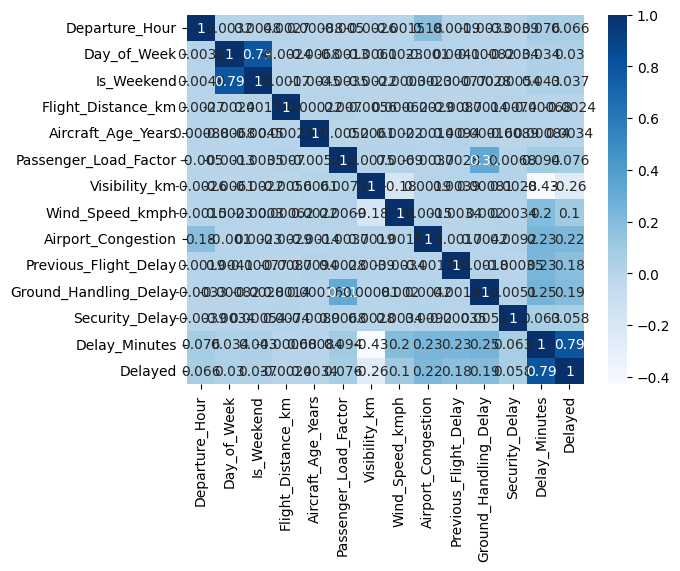

In [60]:
sns.heatmap(correlation,annot=True,cmap='Blues')

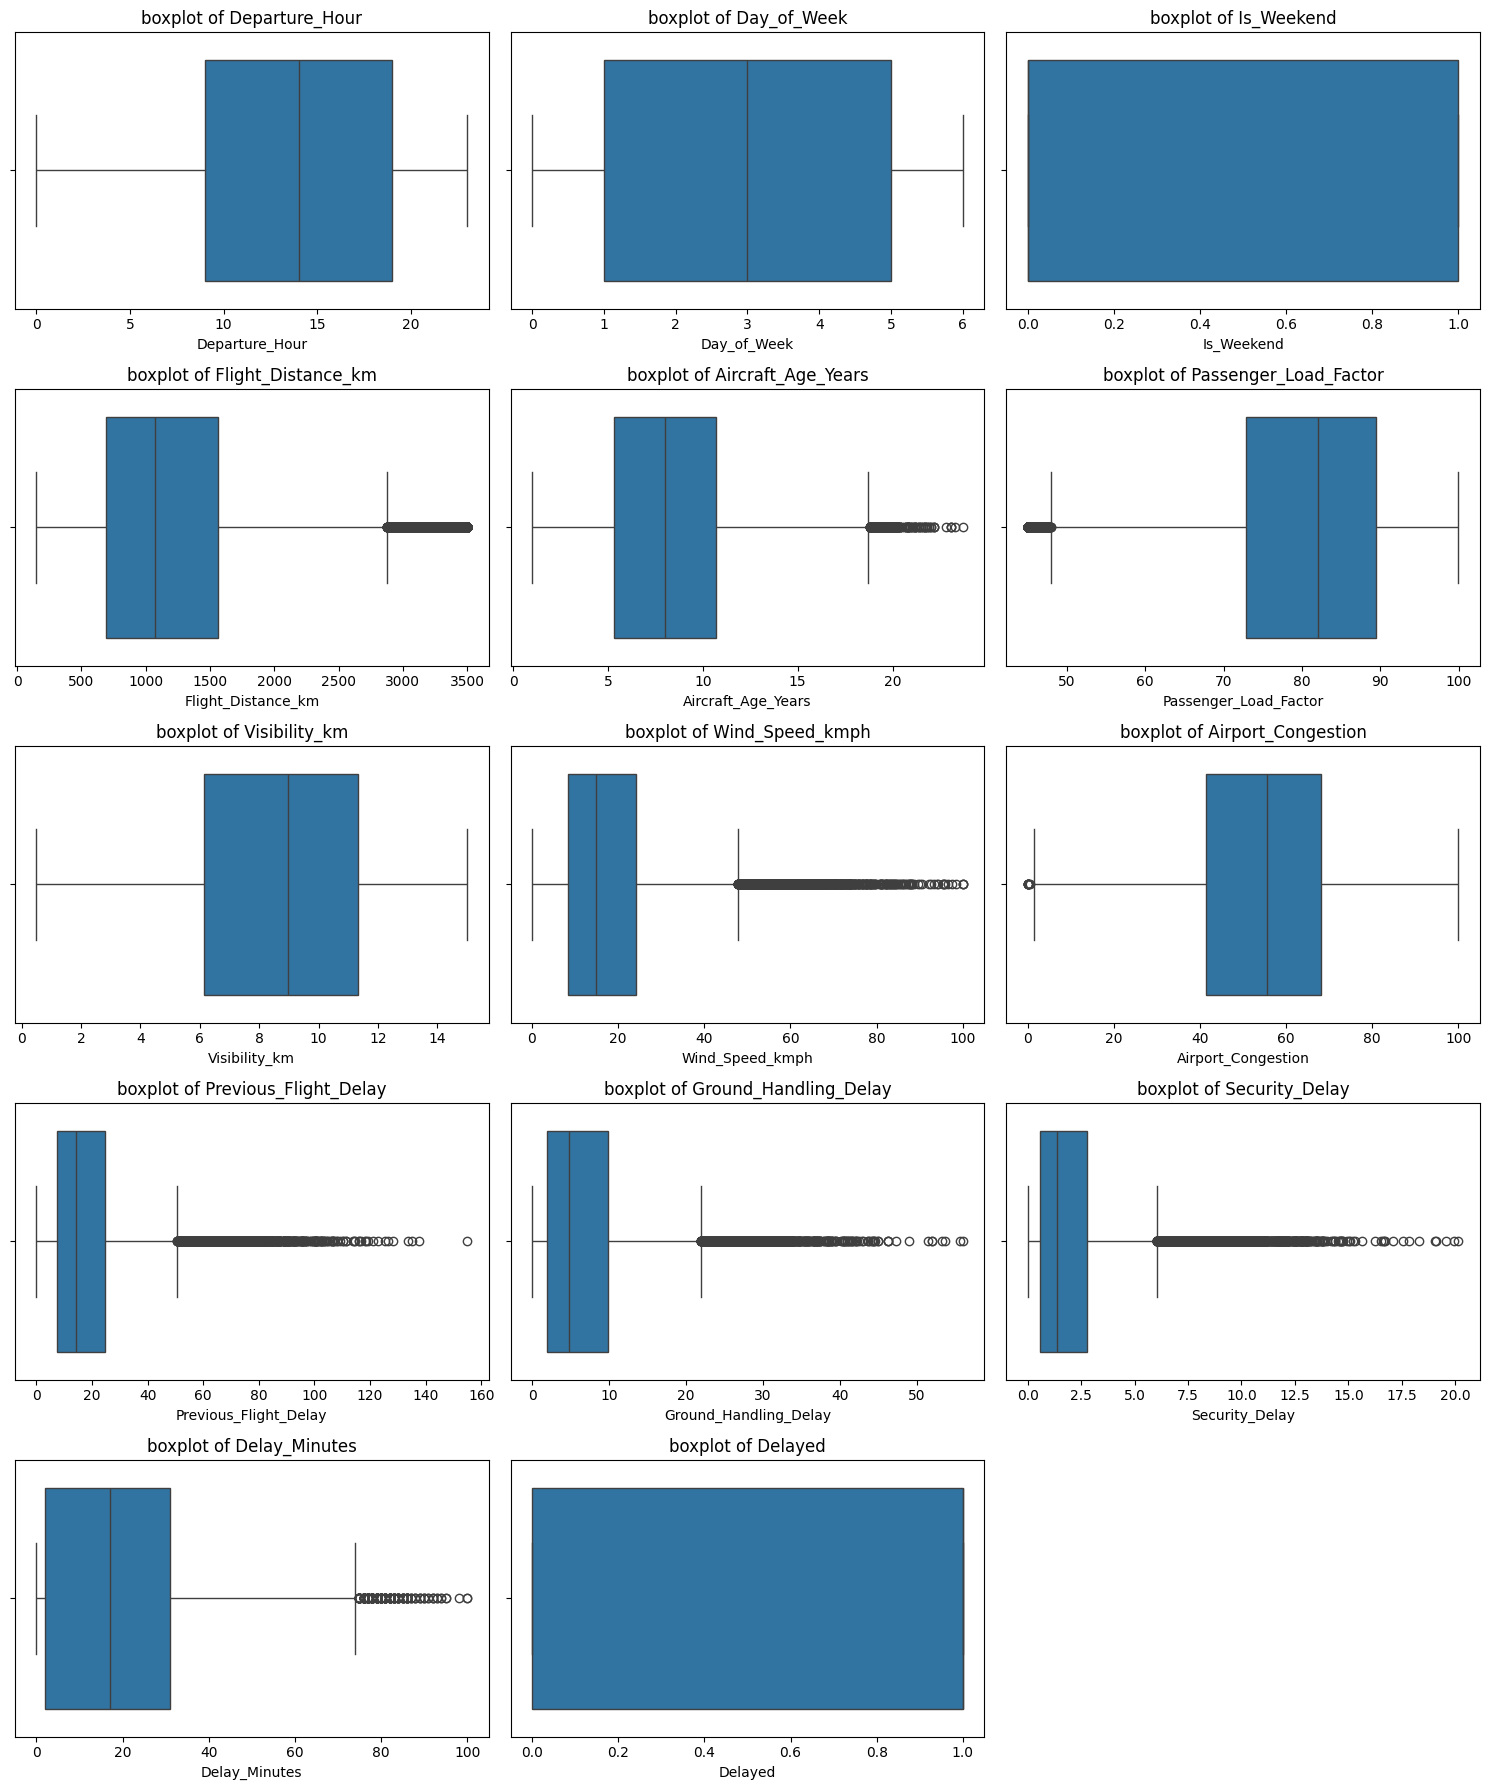

In [61]:
plt.figure(figsize=(15, 18))

numeric_columns = [
    'Departure_Hour', 'Day_of_Week', 'Is_Weekend', 'Flight_Distance_km',
    'Aircraft_Age_Years', 'Passenger_Load_Factor', 'Visibility_km',
    'Wind_Speed_kmph', 'Airport_Congestion', 'Previous_Flight_Delay',
    'Ground_Handling_Delay', 'Security_Delay', 'Delay_Minutes', 'Delayed'
]

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(data=df, x=column)
    plt.title(f'boxplot of {column}')

plt.tight_layout()
plt.show()

In [62]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]  # outliers
    print(f"outliers detected in '{column}' columns:\n", outliers, '\n')

    # Capping outliers to the bounds
    # Use the clip method to cap the outliers to the upper and lower bounds
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

print("data after removing outliers:\n", df)

outliers detected in 'Departure_Hour' columns:
 Empty DataFrame
Columns: [Flight_ID, Airline, Departure_Airport, Arrival_Airport, Flight_Date, Departure_Hour, Day_of_Week, Is_Weekend, Flight_Distance_km, Aircraft_Age_Years, Passenger_Load_Factor, Weather_Condition, Visibility_km, Wind_Speed_kmph, Airport_Congestion, Air_Traffic_Level, Previous_Flight_Delay, Ground_Handling_Delay, Security_Delay, Delay_Minutes, Delayed]
Index: []

[0 rows x 21 columns] 

outliers detected in 'Day_of_Week' columns:
 Empty DataFrame
Columns: [Flight_ID, Airline, Departure_Airport, Arrival_Airport, Flight_Date, Departure_Hour, Day_of_Week, Is_Weekend, Flight_Distance_km, Aircraft_Age_Years, Passenger_Load_Factor, Weather_Condition, Visibility_km, Wind_Speed_kmph, Airport_Congestion, Air_Traffic_Level, Previous_Flight_Delay, Ground_Handling_Delay, Security_Delay, Delay_Minutes, Delayed]
Index: []

[0 rows x 21 columns] 

outliers detected in 'Is_Weekend' columns:
 Empty DataFrame
Columns: [Flight_ID, Airlin

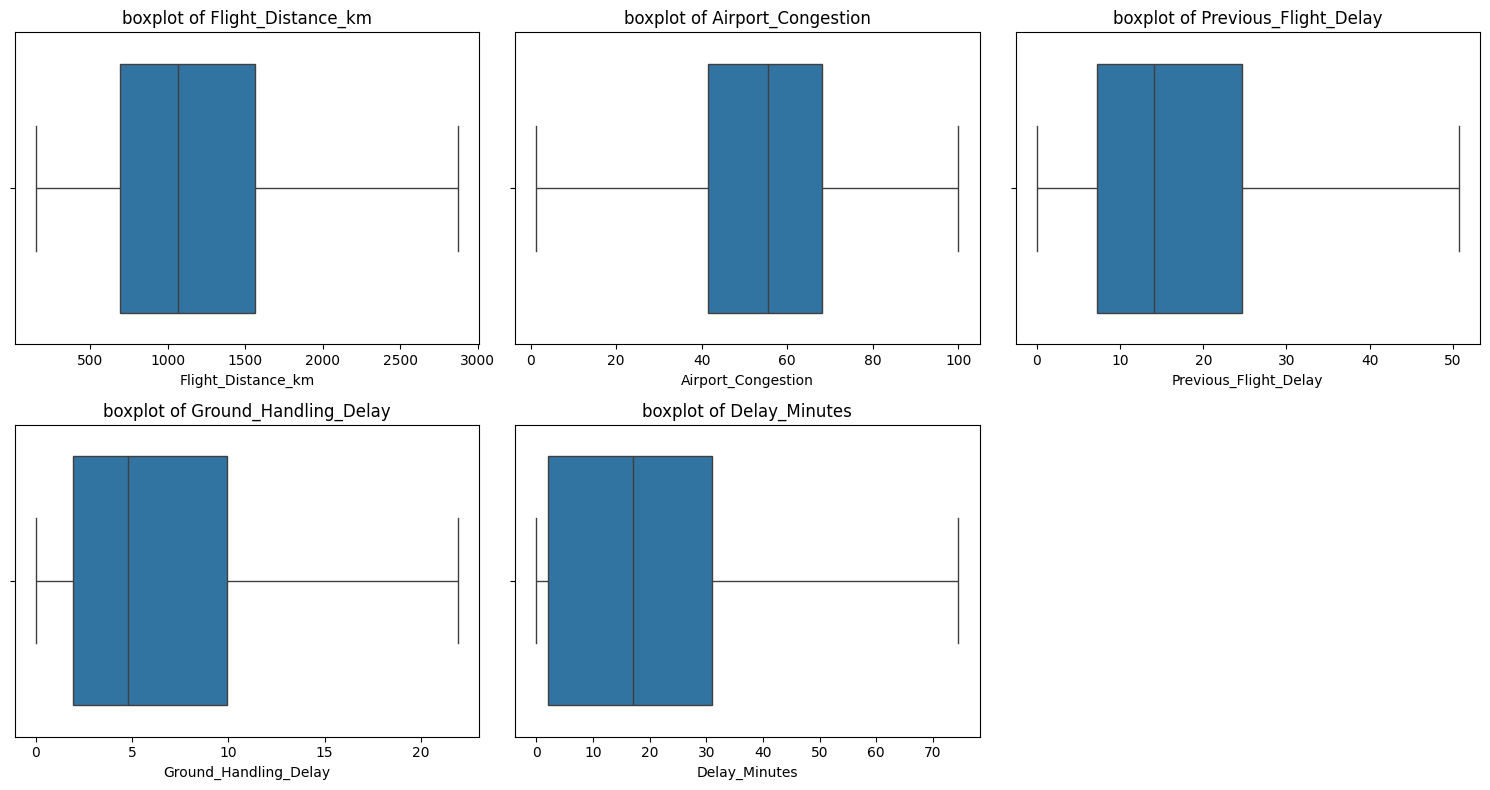

In [63]:
# 5 key continuous flight delay columns
numeric_columns = [
    "Flight_Distance_km",
    "Airport_Congestion",
    "Previous_Flight_Delay",
    "Ground_Handling_Delay",
    "Delay_Minutes",
]

plt.figure(figsize=(15, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=column)
    plt.title(f"boxplot of {column}")

plt.tight_layout()
plt.show()

In [64]:
lb = LabelEncoder()
df['Airline'] = lb.fit_transform(df['Airline'])
df['Weather_Condition'] = lb.fit_transform(df['Weather_Condition'])

In [70]:
x = data.drop(['Flight_ID', 'Flight_Date', 'Delay_Minutes', 'Delayed'], axis=1)
y = data['Delay_Minutes']

In [71]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [75]:
from sklearn.linear_model import LogisticRegression

model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[-0.01, 0.11,-0. ,..., 0.28, 0.68, 0.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['Airline','Departure_Airport','Arrival_Airport',..., 'Previous_Flight_Delay','Ground_Handling_Delay','Security_Delay']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.57
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,17


In [74]:
print(f"Model trained successfully! R^2 Score: {model.score(x_test, y_test):.4f}")

Model trained successfully! R^2 Score: 0.3723


In [76]:
y_pred=model.predict(x_test)
y_pred

array([34.19156927, 26.45423086, 14.62400184, ..., 39.45138245,
       21.243961  , 14.94074596], shape=(15000,))

In [77]:
model.score(x_test,y_test)

0.37226404905355415

In [80]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)


188.76026071224751

In [79]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

10.575791018589342

In [81]:
import numpy as np
print(np.sqrt(mean_squared_error(y_test,y_pred)))

13.739005084512034
